# Outstanding Snowball and Phoenix Notes

This example uses **synthetic teaching note terms, historical fixings and payment records** with the committed 2026-10-08 LSEG SPX spot/discount/forward snapshot. It does not describe an observed issued trade. The issue-date comparison uses separate, explicitly synthetic flat curves; it is not a historical market reconstruction.

The native dated API keeps the original reference, contractual observation dates, historical knock-in and Phoenix memory. Economic observations and settlement records are separate. See the [dated-note guide](../docs/dated_notes.md) for exact conventions. The notebook opens no supplier session and uses no credentials.

In [1]:
from pathlib import Path
from datetime import date, timedelta
from time import perf_counter
import json
import sys
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")
import fuzzy_enigma as fe

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from tools.market_validation import context_from_snapshot
from tools.market_validation.snapshot import read_snapshot, versions

PATHS, SEED, MAX_STEP_DAYS = 12_000, 42, 3.0
FIXTURE = ROOT / "tests/fixtures/market/lseg_spxw_20261008_surface.json"
snapshot = read_snapshot(FIXTURE)
AS_OF = snapshot["source"]["as_of"]
CURRENCY, ASSET = "USD", snapshot["source"]["underlying_ric"]
FUTURE_FIXINGS = ["2026-11-06", "2026-12-04", "2026-12-31", "2027-03-31"]
market_grid = fe.TimeGrid(AS_OF, FUTURE_FIXINGS, max_step_days=MAX_STEP_DAYS)
context, audit = context_from_snapshot(FIXTURE, currency=CURRENCY, time_grid=market_grid)
engine = fe.McEngine(paths=PATHS, seed=SEED, antithetic=True, parallel=True)
GBM_VOL = 0.20
HESTON_PARAMS = dict(v0=0.04, kappa=1.5, theta=0.04, xi=0.4, rho=-0.7)
dynamics = {"GBM": fe.GbmDynamics(GBM_VOL), "Heston": fe.HestonDynamics(**HESTON_PARAMS)}
run_config = dict(as_of=AS_OF, cutoff=context.cutoff.phase, currency=CURRENCY, asset=ASSET,
                  paths=PATHS, seed=SEED, antithetic=True, parallel=True,
                  max_step_days=MAX_STEP_DAYS, market_steps=market_grid.steps,
                  gbm_volatility=GBM_VOL, heston=HESTON_PARAMS,
                  history="synthetic teaching inputs", market_fixture=FIXTURE.name,
                  day_count="ACT/365F", calendar="explicit dates; no holiday adjustment",
                  versions=versions())
print(json.dumps(run_config, indent=2, sort_keys=True))
print("Audit hashes:", json.dumps({k: v for k, v in audit.items() if "sha256" in k}, indent=2))
print("Captured spot:", context.spot, "index points; note PV/coupons below are USD per 100 notional.")

{
  "antithetic": true,
  "as_of": "2026-10-08",
  "asset": ".SPX",
  "calendar": "explicit dates; no holiday adjustment",
  "currency": "USD",
  "cutoff": "after_fixing",
  "day_count": "ACT/365F",
  "gbm_volatility": 0.2,
  "heston": {
    "kappa": 1.5,
    "rho": -0.7,
    "theta": 0.04,
    "v0": 0.04,
    "xi": 0.4
  },
  "history": "synthetic teaching inputs",
  "market_fixture": "lseg_spxw_20261008_surface.json",
  "market_steps": 59,
  "max_step_days": 3.0,
  "parallel": true,
  "paths": 12000,
  "seed": 42,
  "versions": {
    "QuantLib": "1.40",
    "fuzzy-enigma": "0.1.0",
    "lseg-data": "2.1.1",
    "matplotlib": "3.9.0",
    "numpy": "1.26.4",
    "pandas": "2.2.2",
    "scipy": "1.13.1"
  }
}
Audit hashes: {
  "parent_dataset_sha256": "6a6a20fe0a700a3a560bf520e88f6bc84fbf186c6fd22bc7989f85307c68ba1f",
  "parent_capture_dataset_sha256": "3fd44b028b20a9ab77bd5bbdd8585016fa26c563aab7d51b54830558b14f6281",
  "derived_curve_sha256": "0471ee309fc63b90c9b922f12c2e48397ad361d30

## Original Terms, Knock-in, Memory and Partial Settlement

The teaching issue date is 2026-07-08, the reference fixing is 8,000, and notional is USD 100. Knock-in is observed only on the specified dates at 5,600. Phoenix coupons pay USD 2 when spot is at least 7,600; missed periods have memory. Autocall starts on the valuation date at 8,400. Scheduled payments are seven calendar days after their earning fixings, with no business-day adjustment.

The synthetic August fixing 5,400 causes knock-in and a missed coupon. September spot 7,800 earns two coupon periods (USD 4). An explicit USD 1.50 payment leaves USD 2.50 overdue; its expected payment is explicitly declared as 2026-10-15. The October fixing uses the recorded snapshot spot and earns another USD 2 coupon, also due October 15. Recovery does not erase knock-in.

In [2]:
ISSUE, REFERENCE, NOTIONAL = "2026-07-08", 8_000.0, 100.0
COUPON_DATES = ["2026-08-07", "2026-09-08", AS_OF] + FUTURE_FIXINGS
KI_DATES = [ISSUE] + COUPON_DATES

def plus_days(value, days):
    return (date.fromisoformat(value) + timedelta(days=days)).isoformat()

def schedule(dates, lag=7):
    return fe.EventSchedule(dates, [plus_days(d, lag) for d in dates],
                            "explicit synthetic teaching dates; no holiday adjustment")

coupons = schedule(COUPON_DATES)
autocall = schedule([AS_OF] + FUTURE_FIXINGS)
maturity = schedule(["2027-03-31"])
snowball = fe.DatedSnowballNote(NOTIONAL, REFERENCE, 0.12, 5_600.0, 8_400.0,
    ISSUE, CURRENCY, ASSET, KI_DATES, autocall, maturity)
phoenix = fe.DatedPhoenixNote(NOTIONAL, REFERENCE, 2.0, 7_600.0, 5_600.0, 8_400.0,
    ISSUE, CURRENCY, ASSET, KI_DATES, coupons, autocall, maturity, memory=True)
HISTORY = [("2026-08-07", 5_400.0), ("2026-09-08", 7_800.0), (AS_OF, context.spot)]
august_state = fe.replay_note_history(phoenix, HISTORY[:1], fe.ValuationCutoff("2026-08-07"))
september_state = fe.replay_note_history(phoenix, HISTORY[:2], fe.ValuationCutoff("2026-09-08"))
partial = fe.SettlementConfirmation(phoenix.cashflow_id("coupon", "2026-09-08"), AS_OF,
    [fe.ActualPayment("synthetic-september-receipt", "2026-09-15", 1.5)], "2026-10-15")
phoenix_state = fe.replay_note_history(phoenix, HISTORY, context.cutoff, settlements=[partial])
snowball_state = fe.replay_note_history(snowball, HISTORY, context.cutoff)
print(pd.DataFrame([
    {"cutoff": s.cutoff.as_of, "knocked_in": s.knocked_in, "first_KI": s.first_knock_in_date,
     "memory_periods": len(s.memory_coupon_ids), "termination": s.termination}
    for s in [august_state, september_state, phoenix_state]
]).to_string(index=False))
print("Contract/history/settlement hashes:", phoenix_state.contract_hash,
      phoenix_state.history_hash, phoenix_state.settlement_hash, sep="\n")

def show_ledger(state):
    rows = state.ledger
    columns = ["kind", "fixing_date", "contractual_payment_date", "expected_payment_date",
               "amount", "paid_amount", "outstanding_amount", "currency"]
    print(pd.DataFrame(rows, columns=columns).to_string(index=False))
    for row in rows:
        print("ID:", row["id"], "\n  component IDs:", row["component_ids"],
              "\n  actual payments:", row["payments"])

show_ledger(phoenix_state)
assert phoenix_state.knocked_in and not phoenix_state.memory_coupon_ids
assert math.isclose(sum(r["paid_amount"] for r in phoenix_state.ledger), 1.5)
assert math.isclose(sum(r["outstanding_amount"] for r in phoenix_state.ledger), 4.5)

    cutoff  knocked_in   first_KI  memory_periods termination
2026-08-07        True 2026-08-07               1      active
2026-09-08        True 2026-08-07               0      active
2026-10-08        True 2026-08-07               0      active
Contract/history/settlement hashes:
9cfdfe29913b9e0044c7f311d9b2e8a97957a5e20529243568b9f09483224b7e
479ff2cd2043a83db19b012a3ceb14c33488d21daa63dc8831f9dbf5b593590e
fa103b0836f329298ac4e18602fab6f9738be5515a3dce4869a73d26600db887
  kind fixing_date contractual_payment_date expected_payment_date  amount  paid_amount  outstanding_amount currency
coupon  2026-09-08               2026-09-15            2026-10-15     4.0          1.5                 2.5      USD
coupon  2026-10-08               2026-10-15            2026-10-15     2.0          0.0                 2.0      USD
ID: 9cfdfe29913b9e0044c7f311d9b2e8a97957a5e20529243568b9f09483224b7e:coupon:2026-09-08 
  component IDs: ['9cfdfe29913b9e0044c7f311d9b2e8a97957a5e20529243568b9f09483224b7e:c

## Issue-date and Mid-life Prices under GBM and Heston

Issue-date curves below are **synthetic**: 3% discounting and 1% stock carry. Mid-life prices use the dated saved LSEG curves and the replayed state. These prices differ in market inputs, remaining time and realised history; their difference is not attributed solely to knock-in. GBM volatility and Heston parameters are illustrative, not fitted to the option snapshot. Monte Carlo error bars measure sampling only; Heston retains full-truncation discretisation bias.

In [3]:
issue_end = "2027-04-07"
issue_t = (date.fromisoformat(issue_end) - date.fromisoformat(ISSUE)).days / 365.0
issue_d = fe.DiscountCurve(ISSUE, CURRENCY, [ISSUE, issue_end],
    [1.0, math.exp(-0.03*issue_t)], "synthetic issue-date flat discount")
issue_f = fe.ForwardCurve(ISSUE, CURRENCY, ASSET, [ISSUE, issue_end],
    [REFERENCE, REFERENCE*math.exp(0.01*issue_t)], "synthetic issue-date flat carry")
issue_context = fe.ValuationContext(fe.ValuationCutoff(ISSUE), REFERENCE,
    CURRENCY, ASSET, issue_d, issue_f, "synthetic issue-date market")
issue_grid = fe.TimeGrid(ISSUE, COUPON_DATES, max_step_days=MAX_STEP_DAYS)
records, results = [], {}
for product, contract, current_state, method in [
    ("Snowball", snowball, snowball_state, engine.price_snowball_dated),
    ("Phoenix", phoenix, phoenix_state, engine.price_phoenix_dated),
]:
    initial_state = fe.replay_note_history(contract, [], issue_context.cutoff)
    for stage, ctx, state, grid in [("Issue: synthetic curves", issue_context, initial_state, issue_grid),
                                    ("Mid-life: saved curves", context, current_state, market_grid)]:
        for model, parameters in dynamics.items():
            start = perf_counter()
            result = method(contract, ctx, parameters, state, grid=grid)
            elapsed = perf_counter() - start
            results[(product, stage, model)] = result
            records.append(dict(product=product, stage=stage, model=model, price=result.price,
                std_error=result.std_error, samples=result.samples, paths=result.paths,
                steps=grid.steps, seed=SEED, seconds=elapsed, method=result.method,
                grid_hash=result.grid_identity, context_hash=result.context_identity))
price_table = pd.DataFrame(records)
print(price_table.drop(columns=["grid_hash", "context_hash"]).to_string(index=False))
print("Simulation identities:")
print(price_table[["product", "stage", "model", "grid_hash", "context_hash"]].to_string(index=False))

 product                   stage  model      price  std_error  samples  paths  steps  seed  seconds method
Snowball Issue: synthetic curves    GBM 103.610810   0.056945     6000  12000     90    42 0.010380     mc
Snowball Issue: synthetic curves Heston 101.824430   0.093870     6000  12000     90    42 0.010625     mc
Snowball  Mid-life: saved curves    GBM  95.205410   0.048230     6000  12000     59    42 0.006631     mc
Snowball  Mid-life: saved curves Heston  95.613185   0.067084     6000  12000     59    42 0.008691     mc
 Phoenix Issue: synthetic curves    GBM 105.519015   0.067121     6000  12000     90    42 0.017827     mc
 Phoenix Issue: synthetic curves Heston 104.397463   0.098088     6000  12000     90    42 0.019432     mc
 Phoenix  Mid-life: saved curves    GBM 101.955968   0.065344     6000  12000     59    42 0.011013     mc
 Phoenix  Mid-life: saved curves Heston 102.619309   0.083200     6000  12000     59    42 0.012427     mc
Simulation identities:
 product      

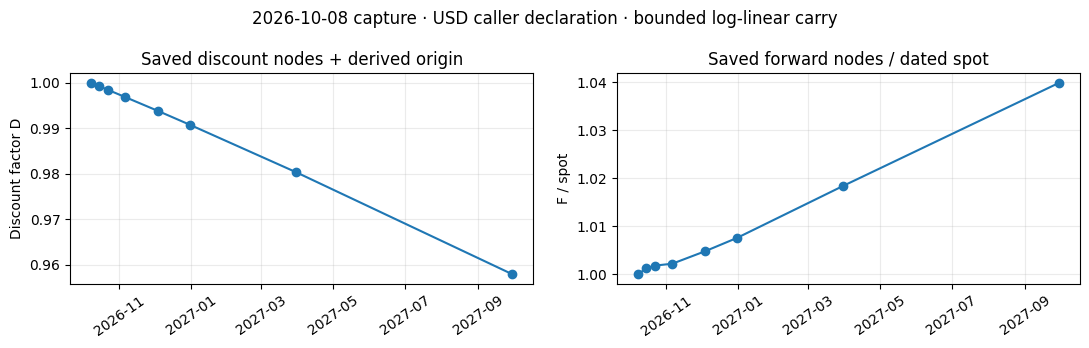

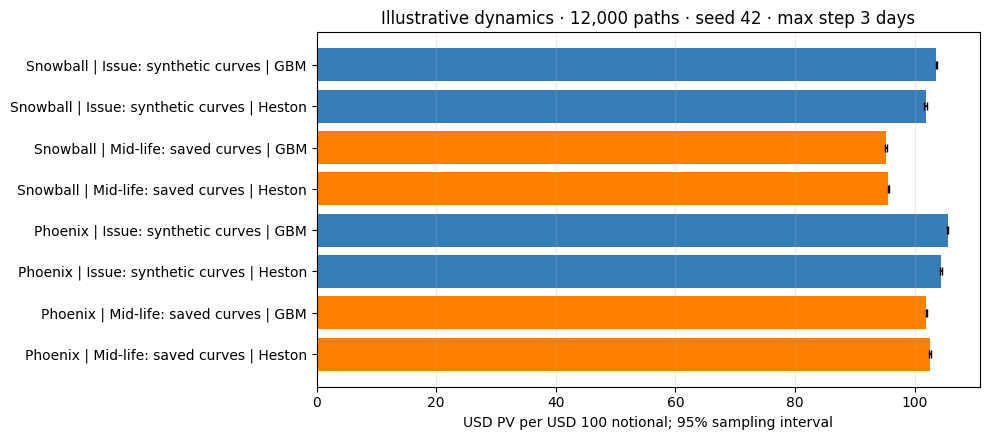

In [4]:
nodes = [audit["origin_anchor"]] + audit["captured_nodes"]
node_dates = pd.to_datetime([n["date"] for n in nodes])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(node_dates, [n["discount_factor"] for n in nodes], "o-")
axes[0].set_title("Saved discount nodes + derived origin")
axes[0].set_ylabel("Discount factor D")
axes[1].plot(node_dates, [n["forward"]/context.spot for n in nodes], "o-")
axes[1].set_title("Saved forward nodes / dated spot")
axes[1].set_ylabel("F / spot")
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.25)
fig.suptitle("2026-10-08 capture · USD caller declaration · bounded log-linear carry")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
labels = [f"{r.product} | {r.stage} | {r.model}" for r in price_table.itertuples()]
positions = np.arange(len(labels))
ax.barh(positions, price_table.price, xerr=1.96*price_table.std_error, capsize=3,
        color=["#377eb8" if r.stage.startswith("Issue") else "#ff7f00" for r in price_table.itertuples()])
ax.set_yticks(positions, labels)
ax.invert_yaxis()
ax.set_xlabel("USD PV per USD 100 notional; 95% sampling interval")
ax.set_title(f"Illustrative dynamics · {PATHS:,} paths · seed {SEED} · max step {MAX_STEP_DAYS:g} days")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Known Balances and Future Expected Cashflows

The known USD 4.50 balance is already earned and excludes the USD 1.50 paid receipt. Future model-dependent coupons/principal are separately estimated. The following table comes from the native result; its present values sum to the reported price. Plot totals are grouped by payment date for display; coupon and principal obligations retain separate ledger IDs.

     kind fixing_date payment_date  expected_amount  amount_std_error  present_value  pv_std_error
   coupon  2026-09-08   2026-10-15         2.500000          0.000000       2.498114      0.000000
   coupon  2026-10-08   2026-10-15         2.000000          0.000000       1.998491      0.000000
   coupon  2026-11-06   2026-11-13         1.353500          0.006172       1.348214      0.006148
   coupon  2026-12-04   2026-12-11         1.379500          0.011387       1.369850      0.011307
   coupon  2026-12-31   2027-01-07         1.228167          0.014507       1.215809      0.014361
   coupon  2027-03-31   2027-04-07         1.278167          0.017541       1.251915      0.017181
principal  2026-11-06   2026-11-13         6.900000          0.222651       6.873050      0.221781
principal  2026-12-04   2026-12-11        10.600000          0.263853      10.525853      0.262007
principal  2026-12-31   2027-01-07         9.108333          0.249171       9.016688      0.246664
principal 

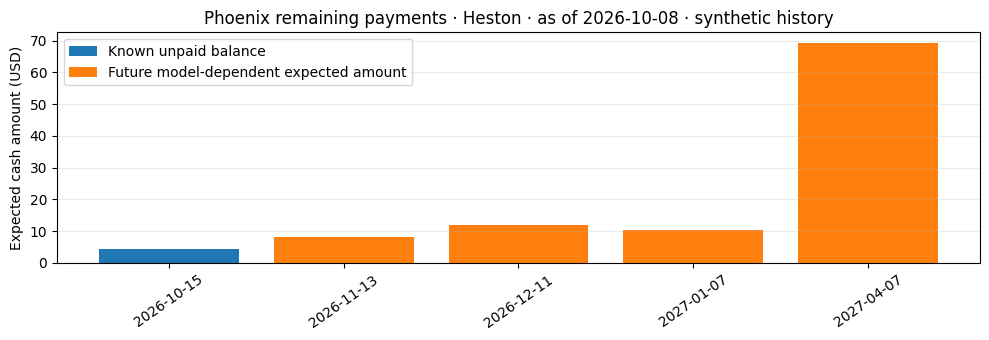

In [5]:
midlife = results[("Phoenix", "Mid-life: saved curves", "Heston")]
expected = pd.DataFrame(midlife.expected_cashflows)
print(expected[["kind", "fixing_date", "payment_date", "expected_amount", "amount_std_error",
                "present_value", "pv_std_error"]].to_string(index=False))
assert math.isclose(expected.present_value.sum(), midlife.price, rel_tol=1e-12, abs_tol=1e-10)
known_by_date = {}
for row in phoenix_state.known_receivables:
    d = row["expected_payment_date"]
    known_by_date[d] = known_by_date.get(d, 0.0) + row["outstanding_amount"]
amounts = expected.groupby("payment_date")["expected_amount"].sum().sort_index()
known = np.array([known_by_date.get(d, 0.0) for d in amounts.index])
future = amounts.to_numpy() - known
fig, ax = plt.subplots(figsize=(10, 3.5))
x = np.arange(len(amounts))
ax.bar(x, known, label="Known unpaid balance")
ax.bar(x, future, bottom=known, label="Future model-dependent expected amount")
ax.set_xticks(x, amounts.index, rotation=35)
ax.set_ylabel("Expected cash amount (USD)")
ax.set_title(f"Phoenix remaining payments · Heston · as of {AS_OF} · synthetic history")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Redeemed but Unpaid, and Fully Settled

For a second teaching Phoenix, the autocall barrier equals today's recorded spot. Two earlier coupons were missed; the eligible same-day coupon catches up all three periods (USD 6) before USD 100 principal redemption. Both payments are due October 15. Redemption stops observation, but the unpaid amounts retain deterministic value. Only explicit full receipts remove that value.

In [6]:
redeemed_note = fe.DatedPhoenixNote(NOTIONAL, REFERENCE, 2.0, 7_600.0, 5_600.0, context.spot,
    ISSUE, CURRENCY, ASSET, KI_DATES, coupons, schedule([AS_OF]), maturity, memory=True)
redeemed_history = [("2026-08-07", 5_400.0), ("2026-09-08", 7_500.0), (AS_OF, context.spot)]
redeemed_state = fe.replay_note_history(redeemed_note, redeemed_history, context.cutoff)
no_simulation = fe.McEngine(paths=0, seed=SEED)
pending = no_simulation.price_phoenix_dated(redeemed_note, context, None, redeemed_state)
show_ledger(redeemed_state)
print("Redeemed / unpaid:", pending)
assert redeemed_state.termination == "redeemed"
assert pending.samples == 0 and pending.std_error == 0.0
assert math.isclose(pending.price, 106.0*context.discount_curve.value("2026-10-15"), rel_tol=1e-12)
payments = [fe.SettlementConfirmation(row["id"], "2026-10-15",
    [fe.ActualPayment("synthetic-full-"+row["kind"], "2026-10-15", row["amount"])])
    for row in redeemed_state.ledger]
settled_cutoff = fe.ValuationCutoff("2026-10-15")
settled_state = fe.advance_note_state(redeemed_note, redeemed_state, [], settled_cutoff, settlements=payments)
settled_context = context.frozen_roll(settled_cutoff)
settled = no_simulation.price_phoenix_dated(redeemed_note, settled_context, None, settled_state)
print("Fully settled:", settled, "state provenance:", settled_state.provenance)
show_ledger(settled_state)
assert settled.price == 0.0 and settled.samples == 0

     kind fixing_date contractual_payment_date expected_payment_date  amount  paid_amount  outstanding_amount currency
   coupon  2026-10-08               2026-10-15            2026-10-15     6.0          0.0                 6.0      USD
principal  2026-10-08               2026-10-15            2026-10-15   100.0          0.0               100.0      USD
ID: e2f32c906fa52b4288da664ca26b0d4e451b8921b63eb30b66bf09c5a169a16c:coupon:2026-10-08 
  component IDs: ['e2f32c906fa52b4288da664ca26b0d4e451b8921b63eb30b66bf09c5a169a16c:coupon_period:2026-08-07', 'e2f32c906fa52b4288da664ca26b0d4e451b8921b63eb30b66bf09c5a169a16c:coupon_period:2026-09-08', 'e2f32c906fa52b4288da664ca26b0d4e451b8921b63eb30b66bf09c5a169a16c:coupon_period:2026-10-08'] 
  actual payments: []
ID: e2f32c906fa52b4288da664ca26b0d4e451b8921b63eb30b66bf09c5a169a16c:principal:2026-10-08 
  component IDs: [] 
  actual payments: []
Redeemed / unpaid: DatedPriceResult(price=105.920018, std_error=0.000000, method=deterministic)
Fully

## Frozen Calendar Theta and Cash Reconciliation

The roll fixes the contractual dates, freezes spot and dynamics, and rebases the same saved curves. It is a scenario, not another market capture. An event-free roll to October 9 changes the undiscounted-date PV of pending balances. Rolling through payment requires explicit receipts; the cashflow is not marked paid merely because October 15 passes. The result separates PV change, actual paid cash and the change measured back in the original valuation numeraire. Existing legacy Greeks retain schedule-scaled `dV/dT`.

In [7]:
event_free = no_simulation.calendar_theta(redeemed_note, context, None, redeemed_state, "2026-10-09")
paid_roll = no_simulation.calendar_theta(redeemed_note, context, None, redeemed_state,
    "2026-10-15", settlements=payments)
rolled_theta_grid = fe.TimeGrid("2026-10-09", FUTURE_FIXINGS, max_step_days=MAX_STEP_DAYS)
active_roll = engine.calendar_theta(phoenix, context, dynamics["GBM"], phoenix_state,
    "2026-10-09", grid=market_grid, rolled_grid=rolled_theta_grid)
print("Paired theta grid config:", dict(base_steps=market_grid.steps,
    rolled_steps=rolled_theta_grid.steps, max_step_days=MAX_STEP_DAYS,
    base_hash=market_grid.identity, rolled_hash=rolled_theta_grid.identity))
roll_rows = []
for label, roll in [("Event-free pending balance", event_free), ("Explicit full payment", paid_roll),
                    ("Active Phoenix: paired GBM", active_roll)]:
    roll_rows.append(dict(scenario=label, roll_days=roll.roll_days,
        base_pv=roll.base_price, rolled_pv=roll.rolled_price, pv_change=roll.pv_change,
        cash_paid=roll.cash_paid, cash_adjusted_change=roll.cash_adjusted_change,
        theta_per_day=roll.theta_per_day, theta_per_year=roll.theta_per_year,
        std_error=roll.std_error, state_provenance=roll.rolled_state.provenance))
print(pd.DataFrame(roll_rows).to_string(index=False))
assert event_free.std_error == 0.0 and paid_roll.std_error == 0.0
assert math.isclose(paid_roll.cash_paid, 106.0, rel_tol=1e-12)
assert abs(event_free.cash_adjusted_change) < 1e-10
assert abs(paid_roll.cash_adjusted_change) < 1e-10
assert math.isfinite(active_roll.pv_change) and active_roll.std_error >= 0.0
print("No new market snapshot, no surface roll and no recalibration were used.")

Paired theta grid config: {'base_steps': 59, 'rolled_steps': 59, 'max_step_days': 3.0, 'base_hash': '9dc64b150fbdec2555eec76999e87221ac2c3d8fe456b724038b6c19ef2da270', 'rolled_hash': 'bad4f3b8dec0c6ef7659dd6292bfc2e4314c33451e097be1fa3276b5036f072e'}
                  scenario  roll_days    base_pv  rolled_pv   pv_change  cash_paid  cash_adjusted_change  theta_per_day  theta_per_year  std_error state_provenance
Event-free pending balance          1 105.920018 105.931441    0.011422        0.0               0.00000       0.011422        4.169129   0.000000      frozen_roll
     Explicit full payment          7 105.920018   0.000000 -105.920018      106.0               0.00000     -15.131431    -5522.972379   0.000000      frozen_roll
Active Phoenix: paired GBM          1 102.014280 102.053845    0.039565        0.0               0.02856       0.039565       14.441079   0.016901      frozen_roll
No new market snapshot, no surface roll and no recalibration were used.


The examples isolate cashflow accounting from stochastic valuation: historical knock-in survives recovery; memory is paid only on an eligible fixing; explicit partial/full receipts determine balances; and redemption does not imply settlement. The model comparison reports sampling error and runtime, while numerical grid bias, illustrative dynamics and synthetic history remain separate assumptions.